# Analysis — N Particles

In [14]:
import matplotlib.pyplot as plt
import numpy as np
np.seterr('warn')

from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, get_xf_yf_fund, get_mean_amp_and_phase, get_fft

## Configuração
Edite apenas esta célula para adicionar/remover partículas ou frequências.

In [15]:
# filenames_all = fetch_data_filenames("./20-05-26")
filenames_all = fetch_data_filenames("./26-05-26_27-05-26")

In [16]:
# filenames_all = fetch_data_filenames("./23-05-26")
exc_data_npy = [
    extract_data_info_from_path(data_path_npy) for data_path_npy in filenames_all 
    if ("step" in data_path_npy) and (".npy" in data_path_npy) and ("amp_offset_laser" in data_path_npy)
    ]

In [17]:
freq_list = sorted(set([dic["freq"] for dic in exc_data_npy]))

# Layout dos subplots de verificação visual
cols = 4
rows = int(np.ceil(len(freq_list) / cols))
    

## Análise — loop sobre N partículas

In [18]:
def time_domain_visual_verification(particles: list):

    for p_idx, p_dic in enumerate(particles):
        particle_label = f"Particle {p_dic['p_label']}"
        # correct = adj_phase_correction[p_idx] if p_idx < len(adj_phase_correction) else False

        print(f"\n{'='*50}")
        print(f"  Processing particle {p_dic['p_label']}  ")
        print(f"{'='*50}")

        omegas      = []
        phase_diffs = []

        # ---- Subplots de verificação visual ----
        fig, axs = plt.subplots(rows, cols, figsize=(12, 12), constrained_layout=True)
        fig.suptitle(f"Particle {p_dic["p_label"]}", fontsize=14)

        # data = p_dic["p_data"]

        for index, step_data in enumerate(p_dic["p_data"]):
            freq = step_data["freq"]
            i, j = divmod(index, cols)
            omega = 2 * np.pi * float(freq) * 1e-6
            omegas.append(omega)

            # Colocar para fazer calcular fases média

            ax = axs[i, j]
            for idx_rep, rep in enumerate(step_data["data"]):
                ax.plot(rep[:,0], rep[:,1])

            ax.set_title(f"{freq} Hz")


        plt.show()

# time_domain_visual_verification(p_list)

## Get mean phases and errors

In [19]:
# #Calculate list of phasors for the laser and all measurements
# for step in exc_data_npy:
#   freq = step["freq"]
#   step["fft_amp_list"] = []
#   for meas_idx, meas in enumerate(step["data"]):
#     _, amp = get_xf_yf_fund(meas[:,0], meas[:,1])
#     step["fft_amp_list"].append(amp)

# # Get mean phase and error for each particle and each step (freq) 
# for step in exc_data_npy:
#     freq = step["freq"]
#     amp_list = step["fft_amp_list"]
#     _, _, phase, phase_error = get_mean_amp_and_phase(amp_list)
#     step["mean_fft_info"] = [freq, phase, phase_error]

# #Calculate list of phasors for all particles and all measurements
# for p in p_list:
#   for step in p["p_data"]:
#     freq = step["freq"]
#     step["fft_amp_list"] = []
#     for meas_idx, meas in enumerate(step["data"]):
#       _, amp = get_xf_yf_fund(meas[:,0], meas[:,1])
#       step["fft_amp_list"].append(amp)

# # Get mean phase and error for each particle and each step (freq) 
# for p in p_list:
#     for step in p["p_data"]:
#         freq = step["freq"]
#         amp_list = step["fft_amp_list"]
#         _, _, phase, phase_error = get_mean_amp_and_phase(amp_list)
#         step["mean_fft_info"] = [freq, phase, phase_error]

## Comparison — all particles

In [20]:
def get_error_bar(exc_data, p_list):
    exc_mean_phase = np.array([
            step["mean_fft_info"]
            #[freq, phase, phase_error]
            for step in exc_data
        ])
    error_exc = exc_mean_phase[:,2]
    # print(error_exc)

    for p in p_list:
        # if p["p_label"] !=1: continue
        p_mean_phase = np.array([
            step["mean_fft_info"]
            for step in p["p_data"]
            ])
        
        if (p_mean_phase[:,0]-exc_mean_phase[:,0]).sum() != 0.:
            print("Deu ruim!")
            return None
        else:
            pd_list = np.unwrap(p_mean_phase[:,1]-exc_mean_phase[:,1])
            pd_error = np.hypot(
                p_mean_phase[:,2],
                exc_mean_phase[:,2]
            )

        p["error_bar"] = np.column_stack((p_mean_phase[:,0], pd_list, pd_error))

# get_error_bar(exc_data_npy, p_list)

In [21]:
def plot_phase_difference(particles: list, p_to_skip = [], freqs_to_skip = []):
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for p_id, p in enumerate(particles):
        if p["p_label"] in p_to_skip: continue
        color = colors[p_id % len(colors)]
        # p["error_bar"]
        label_added = False
        for idx, error_point in enumerate(p["error_bar"]):
            # Skip frequencies larger than 20kHz
            if (error_point[0] in freqs_to_skip): 
                # print(f"Não foi calculado pra freq: {error_point[0]}Hz")
                continue
            
            current_label = f"Particle {p['p_label']}" if not label_added else None

            plt.errorbar(
                error_point[0],
                error_point[1],
                yerr=error_point[2],
                label=current_label,
                fmt='o',
                capsize=5,
                color=color,
            )
            label_added = True
        # plt.title(f"Particle {p['p_label']}  - phase difference")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Phase diferrence (rad)")
        plt.xscale("log")
    
    if len(particles)>1:
        plt_title = f"{len(particles)} Particles - phase difference" 
    else:
        plt_title = f"{len(particles)} Particle - phase difference" 

    plt.title(plt_title)
    plt.legend()
    plt.show()

# plot_phase_difference(p_list, p_to_skip=[], freqs_to_skip=[])

## Signal-Noise relation

In [22]:
def get_snr_db(time, curve, freq=1):
    """
    Calculate the Signal-Noise Relation (SNR) in dB.
    
    Parâmeters:
      freq = 0: The 'signal' is the DC component (zero frequency).
      freq = 1: The 'signal' is the fundamentabl frequency (largest AC spike).
      freq = 1: The 'signal' is 2nd harmonic (2*fundamental_frequency).

    The remaining power of the spectrum is considered noise.
    """
    # 1. Obtém a FFT usando a sua função existente
    xf, yf = get_fft(time, curve)
    
    # 2. Mantém o termo DC e as frequências positivas
    mask_positive = xf >= 0
    xf = xf[mask_positive]
    yf = yf[mask_positive]
    
    # 3. Calcula o espectro de potência (módulo ao quadrado)
    power = np.abs(yf)**2

    # 4. Encontra a frequência fundamental (omega)
    # Ignoramos temporariamente o termo DC para garantir que acharemos o maior pico AC
    power_ac = np.copy(power)
    power_ac[xf == 0] = 0 

    idx_fund = np.argmax(power_ac)
    
    freq_fund = xf[idx_fund]

    idx_dc = np.argmin(np.abs(xf))
    idx_2omega = np.argmin(np.abs(xf - 2*freq_fund))

    
    # 5. Seleciona o índice do sinal de interesse com base no parâmetro 'freq'
    if freq == 0:
        # Sinal é o termo DC (frequência mais próxima de 0)
        idx_signal = idx_dc
        
    elif freq == 1:
        # Sinal é a frequência fundamental (omega)
        idx_signal = idx_fund
        
    elif freq == 2:
        # Sinal é o segundo harmônico (2 * omega)
        idx_signal = idx_2omega
        
    else:
        raise ValueError("O parâmetro 'freq' deve ser 0, 1 ou 2.")

    # Extrai a potência do sinal selecionado
    p_signal = power[idx_signal]
    
    # Opcional: print para debug/verificação
    # print(f"Modo: freq={freq} | Freq Sinal: {xf[idx_signal]:.4f} Hz | Idx: {idx_signal}")

    # Remove a contribuição do DC para o cálculo do ruído (se o sinal não for o DC)
    if freq != 0:
        # Encontra o índice da frequência 0 (geralmente é o índice 0)
        power[idx_dc] = 0.0
    
    # 6. Identifica a potência do Ruído (Potência total - Potência do sinal)
    p_noise = (np.sum(power) - power[idx_fund] - power[idx_dc] - power[idx_2omega])/(len(power)-3)
    
    # Tratamento de segurança: se o sinal for uma senoide perfeita simulada
    if p_noise <= 1e-15:
        return float('inf') 
        
    # 7. Calcula a razão em dB
    snr_db = 10 * np.log10(p_signal / p_noise)
    
    return snr_db

def plot_time_and_freq_domain(time, lum_curve, laser_curve):
    """Plot time and frequency domain of the luminescence and laser curves"""
    # Suponho que a função get_fft já esteja definida no seu código
    xf_laser, yf_laser = get_fft(time, laser_curve)
    xf_lum, yf_lum = get_fft(time, lum_curve)
    
    # Filtering only positive frequencies
    lum_mask = xf_lum > 0
    xf_lum = xf_lum[lum_mask]
    yf_lum = yf_lum[lum_mask]
    laser_mask = xf_laser > 0
    xf_laser = xf_laser[laser_mask]
    yf_laser = yf_laser[laser_mask]

    fig, axs = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)

    # --- DOMÍNIO DO TEMPO ---
    # Eixo principal (Esquerdo - Verde/Lum)
    axs[0].set_xlabel("Time ($\mu$s)")
    axs[0].set_ylabel("Luminescence (a.u.)", color="tab:green")
    line1 = axs[0].plot(time*(1e-6), lum_curve, color="tab:green", label="lum")
    axs[0].tick_params(axis='y', labelcolor="tab:green")
    axs[0].set_title("Time Domain")

    # Eixo secundário (Direito - Vermelho/Laser)
    ax0_twin = axs[0].twinx()
    ax0_twin.set_ylabel("Laser (a.u.)", color="tab:red")
    line2 = ax0_twin.plot(time*(1e-6), laser_curve, color="tab:red", label="laser")
    ax0_twin.tick_params(axis='y', labelcolor="tab:red")

    # Juntando as legendas dos dois eixos
    lines_time = line1 + line2
    labels_time = [l.get_label() for l in lines_time]
    axs[0].legend(lines_time, labels_time, loc="best")


    # --- DOMÍNIO DA FREQUÊNCIA ---
    # Eixo principal (Esquerdo - Verde/Lum)
    axs[1].set_xlabel("Frequency (Hz)")
    axs[1].set_ylabel("Lum Amplitude", color="tab:green")
    line3 = axs[1].plot(xf_lum, np.abs(yf_lum), color="tab:green", label="lum")
    axs[1].tick_params(axis='y', labelcolor="tab:green")
    axs[1].set_title("Frequency Domain")

    # Eixo secundário (Direito - Vermelho/Laser)
    ax1_twin = axs[1].twinx()
    ax1_twin.set_ylabel("Laser Amplitude", color="tab:red")
    line4 = ax1_twin.plot(xf_laser, np.abs(yf_laser), color="tab:red", label="laser")
    ax1_twin.tick_params(axis='y', labelcolor="tab:red")

    # Juntando as legendas dos dois eixos
    lines_freq = line3 + line4
    labels_freq = [l.get_label() for l in lines_freq]
    axs[1].legend(lines_freq, labels_freq, loc="best")

    plt.show()

def plot_amp_offset_laser(amp, offset):
    for step in exc_data_npy:
        if not (step["amp"] in amp and step["offset"] in offset): continue

        time = np.array(step["data"])[0,:,0]
        signal = np.array(step["data"])[:,:,1].mean(axis=0)

        get_snr_db(time, signal, freq=2)

        print(f"offset: {step["offset"]}, amp: {step["amp"]}")
        plot_time_and_freq_domain(time, signal, signal)

# plot_amp_offset_laser([0.45], [0.50])

### SNR for laser

In [25]:
snr_list = []

for step in exc_data_npy:
    time = np.array(step["data"])[0,:,0]
    signal = np.array(step["data"])[:,:,1].mean(axis=0)

    snr_list.append([
        step["amp"],
        step["offset"],
        get_snr_db(time, signal, freq=2) - get_snr_db(time, signal),
    ])

snr_list = np.array(snr_list)

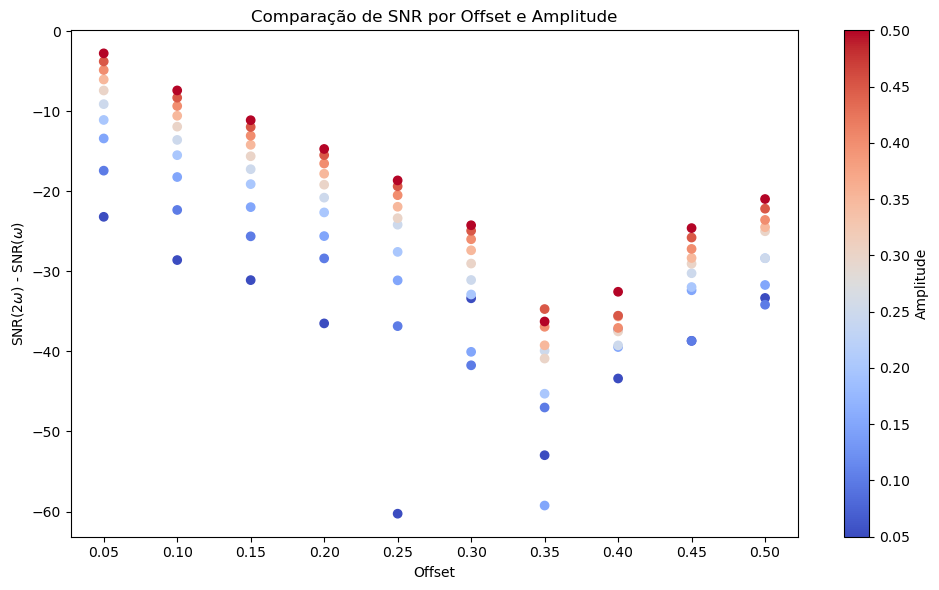

In [ ]:
amps = snr_list[:, 0]
offsets = snr_list[:, 1]
snr_diffs = snr_list[:, 2]

offset_list = sorted(set(offsets))

plt.figure(figsize=(10, 6))

# Plota todos os pontos de uma vez. 
# O parâmetro 'c' define a cor baseada no valor, e 'cmap' define a escala
scatter = plt.scatter(offsets, snr_diffs, c=amps, cmap='coolwarm')

plt.title("Comparação de SNR por Offset e Amplitude")
plt.xlabel("Offset")
plt.xticks(offset_list)
# Usando 'r' antes da string (raw string) evita problemas com as barras do LaTeX no Python
plt.ylabel(r"SNR($2\omega$) - SNR($\omega$)") 

# Adiciona a barra lateral indicando a escala coolwarm
cbar = plt.colorbar(scatter)
cbar.set_label('Amplitude')

plt.tight_layout()
plt.show()

No gráfico acima, quanto mais abaixo os pontos estiverem menor será o SH em relação ao fundamental. Isso é o que desejamos para o laser.
Nós estamos offset = 0.4 e amplitude de 0.5 para nossos experimentos.

In [54]:
for item in snr_list:
    if item[0] == 0.5 and item[1] == 0.4:
        print(f"Para a amplitude e offset dos experimentos, temos que SNR(2omega)-SNR(omega) é: {item[2]:.2f} dB.")

Para a amplitude e offset dos experimentos, temos que SNR(2omega)-SNR(omega) é: -32.56 dB.
